# Does a checksum self-check beat plain critique?

This notebook is a runnable demo of the evaluation from artifact `art_VCF3BbfSo_RV`.

The underlying experiment (`gen_art_experiment_1`) asked four LLM self-check strategies to solve synthetic multi-step arithmetic word problems:

- **baseline** — answer with no self-check
- **freeform_critique** — a free-form "double check your work" critique
- **placebo_critique** — a length-matched critique that does *not* teach a checksum method (controls for "just writing more text helps")
- **checksum_critique** — a critique that explicitly computes a mod-9 digit-root ("casting out nines") checksum on each arithmetic step
- **oracle_detection_isolation** — an ablation arm that is *told* externally whether a checksum mismatch exists, isolating "can the model use a mismatch signal" from "can the model compute one itself"

This demo notebook reproduces the evaluation's core statistics (`eval.py`) on a curated 40-problem subset (`mini_demo_data.json`, 20 checksum-detectable + 20 checksum-invisible problems, one record per model x condition):

1. Reproduce the experiment's deterministic synthetic-problem generation + error-injection seeds, to recover the checksum-detectable ground-truth label per problem.
2. Final-answer accuracy per model x condition (overall / detectable / invisible split) with Wilson 95% confidence intervals.
3. Detection precision/recall/F1 (flagged_error vs. whether the model's own answer was actually wrong).
4. Correction accuracy given a flag, and the oracle-vs-checksum "can compute a checksum" vs "can use one" ablation.
5. Paired McNemar tests + bootstrap CIs (checksum vs freeform, checksum vs placebo) with Holm-Bonferroni correction.

The full evaluation also runs an LLM-judge audit of each checksum computation (`audit_checksum_computation`, Metric 7) — that step calls OpenRouter and needs the full `raw_response` transcripts, which aren't included in this compact demo subset, so it is skipped here (same as running the original script with `--skip-audit`). Everything else is the original `eval.py` logic, split into cells."

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# numpy, scipy — pre-installed on Colab, install locally only (at Colab's exact versions)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'scipy==1.16.3', 'matplotlib==3.10.0')

In [2]:
from __future__ import annotations

import json
import random
import re

import numpy as np
from scipy.stats import binomtest
import matplotlib.pyplot as plt

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-74dec2-checksum-self-critique-helps-weak-arithm/main/round-1/evaluation-1/demo/mini_demo_data.json"
import os

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
records = data["records"]
MODELS_EVALUATED = data["models_evaluated"]
print(f"Loaded {len(records)} prediction records over {data['n_problems']} problems "
      f"({data['n_checksum_detectable']} checksum-detectable, {data['n_checksum_invisible']} checksum-invisible)")
print("Models:", MODELS_EVALUATED)

Loaded 358 prediction records over 40 problems (20 checksum-detectable, 20 checksum-invisible)
Models: ['anthropic/claude-haiku-4.5', 'openai/gpt-4o-mini']


## Config

All tunable parameters live here. `N_PROBLEMS_TO_REPRODUCE` must be large enough to cover every `problem_id` referenced in the loaded records (the original script reproduces the full 200-problem set the experiment was run against, seed=42, and that reproduction is pure local RNG — no LLM calls — so it's cheap enough to use the original full-scale value even in this demo). `N_BOOTSTRAP` and `AUDIT_SAMPLE_SIZE` are reduced from the original script's full-scale values to keep this demo fast; the LLM-judge audit itself (Metric 7) is skipped entirely since it needs `raw_response` transcripts not included in the compact demo data (equivalent to running the original script with `--skip-audit`)."

In [5]:
# N_PROBLEMS_TO_REPRODUCE: how many synthetic problems to regenerate (must cover every
# problem_id in the demo records; original full run used 200, seed=42 -- deterministic
# local RNG, so using the original scale costs nothing extra here)
N_PROBLEMS_TO_REPRODUCE = 200
PROBLEM_GEN_SEED = 42
ERROR_INJECTION_SEED = 7

# N_BOOTSTRAP: bootstrap resamples for the checksum-vs-freeform / checksum-vs-placebo
# CIs (original script used 10,000; reduced here for demo speed)
N_BOOTSTRAP = 2000

CONDITIONS = ["baseline", "freeform_critique", "placebo_critique", "checksum_critique"]
CONDITION_PAIRS_FOR_TEST = [
    ("checksum_critique", "freeform_critique"),
    ("checksum_critique", "placebo_critique"),
]

## Step 1 — Reproduce checksum-detectability ground truth

The experiment generates synthetic arithmetic word problems and injects a wrong digit into one step, then checks whether a mod-9 digit-root ("casting out nines") checksum would catch that specific injected error. Whether an injected error is *checksum-detectable* is not stored per-example in the experiment output, so `eval.py` regenerates the exact same problems and error injections from the same seeds (bit-for-bit) to recover this ground-truth label. This is pure local RNG — no LLM calls."

In [6]:
TEMPLATES = [
    "{name} starts with {a} {unit}. They receive {b} more {unit} from a friend.",
    "A warehouse has {a} {unit}. A shipment of {b} {unit} arrives.",
    "{name} has {a} {unit} and buys {b} more {unit} at the store.",
]
NAMES = ["Maria", "Jamal", "Wei", "Fatima", "Diego", "Priya", "Noah", "Aiko"]
UNITS = ["apples", "boxes", "coins", "stickers", "marbles", "tickets", "widgets"]


class Problem:
    def __init__(self, pid: str, text: str, trace: list, gold_answer: int):
        self.pid = pid
        self.text = text
        self.trace = trace
        self.gold_answer = gold_answer


def gen_synthetic_problem(pid: str, rng: random.Random) -> Problem:
    n_steps = rng.randint(3, 4)
    name = rng.choice(NAMES)
    unit = rng.choice(UNITS)
    a0 = rng.randint(20, 500)
    b0 = rng.randint(10, 300)
    template = rng.choice(TEMPLATES)
    text_parts = [template.format(name=name, unit=unit, a=a0, b=b0)]
    trace = []
    cur = a0 + b0
    trace.append({"a": a0, "op": "+", "b": b0, "result": cur})
    for _ in range(n_steps - 1):
        remaining_ops = ["+", "-", "*"]
        if cur >= 4:
            remaining_ops.append("//")
        op = rng.choice(remaining_ops)
        if op == "+":
            b = rng.randint(5, 200)
            text_parts.append(f"Then {name} receives {b} more {unit}.")
            new_val = cur + b
        elif op == "-":
            b = rng.randint(5, max(6, min(cur - 1, 200)))
            b = min(b, cur - 1) if cur > 1 else 0
            text_parts.append(f"Then {name} gives away {b} {unit}.")
            new_val = cur - b
        elif op == "*":
            b = rng.randint(2, 4)
            text_parts.append(
                f"Then the number of {unit} is multiplied by {b} (e.g. distributed evenly {b} times over)."
            )
            new_val = cur * b
        else:
            b = rng.choice([2, 3, 4, 5])
            text_parts.append(
                f"Then the {unit} are split evenly into {b} groups and {name} keeps one group."
            )
            new_val = cur // b
        trace.append({"a": cur, "op": op, "b": b, "result": new_val})
        cur = new_val
    text_parts.append(f"How many {unit} does {name} have now?")
    return Problem(pid=pid, text=" ".join(text_parts), trace=trace, gold_answer=cur)


def build_problem_set(n: int, seed: int = 42) -> list[Problem]:
    rng = random.Random(seed)
    return [gen_synthetic_problem(f"synth_{i:04d}", rng) for i in range(n)]


def digit_root(x: int) -> int:
    x = abs(int(x))
    if x == 0:
        return 0
    return 1 + (x - 1) % 9


def checksum_consistent(a: int, op: str, b: int, result: int) -> bool:
    da, db, dr = digit_root(a), digit_root(b), digit_root(result)
    if op == "+":
        return (da + db) % 9 == dr % 9 or (da + db == 0 and dr == 0)
    if op == "-":
        return (da - db) % 9 == dr % 9
    if op == "*":
        return (da * db) % 9 == dr % 9 or (da * db == 0 and dr == 0)
    if op == "//":
        if b == 0:
            return False
        remainder = a - b * result
        return checksum_consistent(b, "*", result, a - remainder)
    raise ValueError(f"unknown op {op}")


def inject_error(problem: Problem, rng: random.Random) -> dict | None:
    if not problem.trace:
        return None
    idx = rng.randrange(len(problem.trace))
    step = problem.trace[idx]
    perturb_kind = rng.choice(["off_by_one_digit", "transpose_digits", "off_by_carry"])
    wrong_result = step["result"]
    if perturb_kind == "off_by_one_digit":
        delta = rng.choice([-1, 1]) * rng.choice([1, 10])
        wrong_result = step["result"] + delta
    elif perturb_kind == "transpose_digits":
        s = str(abs(step["result"]))
        if len(s) >= 2:
            i = rng.randrange(len(s) - 1)
            s2 = s[:i] + s[i + 1] + s[i] + s[i + 2 :]
            wrong_result = int(s2) if step["result"] >= 0 else -int(s2)
        else:
            wrong_result = step["result"] + 10
    else:
        wrong_result = step["result"] + rng.choice([-9, 9, -18, 18])
    if wrong_result == step["result"]:
        wrong_result += 1
    return {
        "problem_id": problem.pid,
        "step_index": idx,
        "a": step["a"],
        "op": step["op"],
        "b": step["b"],
        "correct_result": step["result"],
        "wrong_result": wrong_result,
    }


def characterize_errors(problems: list[Problem], seed: int = 7) -> dict:
    """Reproduces method.py's characterize_errors() bit-for-bit to recover the
    per-problem checksum_detectable ground-truth label the experiment used
    internally but did not export per example."""
    rng = random.Random(seed)
    detectable_by_pid: dict[str, bool] = {}
    for problem in problems:
        err = inject_error(problem, rng)
        if err is None:
            continue
        flagged = not checksum_consistent(err["a"], err["op"], err["b"], err["wrong_result"])
        detectable_by_pid[problem.pid] = flagged
    return detectable_by_pid


problems = build_problem_set(N_PROBLEMS_TO_REPRODUCE, seed=PROBLEM_GEN_SEED)
detectable_by_pid = characterize_errors(problems, seed=ERROR_INJECTION_SEED)
n_det = sum(detectable_by_pid.values())
print(f"Reproduced {len(problems)} problems; {n_det}/{len(detectable_by_pid)} have a checksum-detectable injected-error variant")

Reproduced 200 problems; 64/200 have a checksum-detectable injected-error variant


## Step 2 — Statistics helpers

Wilson-score confidence intervals for accuracy, a paired-bootstrap CI on accuracy differences, an exact-binomial McNemar test for paired conditions, and Holm-Bonferroni correction across the resulting family of p-values."

In [7]:
def wilson_ci(k: int, n: int, z: float = 1.959963984540054) -> tuple[float, float]:
    if n == 0:
        return (0.0, 0.0)
    phat = k / n
    denom = 1 + z**2 / n
    center = phat + z**2 / (2 * n)
    margin = z * np.sqrt(phat * (1 - phat) / n + z**2 / (4 * n**2))
    return (float((center - margin) / denom), float((center + margin) / denom))


def bootstrap_ci_diff(a_correct: list[int], b_correct: list[int], n_boot: int = N_BOOTSTRAP, seed: int = 1) -> dict:
    rng = np.random.default_rng(seed)
    a = np.array(a_correct, dtype=float)
    b = np.array(b_correct, dtype=float)
    n = len(a)
    if n == 0:
        return {"diff": 0.0, "ci_low": 0.0, "ci_high": 0.0, "n": 0, "excludes_zero": False}
    idx_boot = rng.integers(0, n, size=(n_boot, n))
    diffs = b[idx_boot].mean(axis=1) - a[idx_boot].mean(axis=1)
    ci_low, ci_high = float(np.percentile(diffs, 2.5)), float(np.percentile(diffs, 97.5))
    return {
        "diff": float(b.mean() - a.mean()),
        "ci_low": ci_low,
        "ci_high": ci_high,
        "n": n,
        "excludes_zero": bool(ci_low > 0 or ci_high < 0),
    }


def mcnemar_test(a_correct: list[int], b_correct: list[int]) -> dict:
    n01 = sum(1 for x, y in zip(a_correct, b_correct) if x == 0 and y == 1)
    n10 = sum(1 for x, y in zip(a_correct, b_correct) if x == 1 and y == 0)
    n_disc = n01 + n10
    if n_disc == 0:
        return {"n01": n01, "n10": n10, "n_discordant": 0, "p_value": 1.0, "method": "exact_binomial_mcnemar"}
    p = binomtest(min(n01, n10), n_disc, 0.5).pvalue
    return {"n01": n01, "n10": n10, "n_discordant": n_disc, "p_value": float(p), "method": "exact_binomial_mcnemar"}


def holm_bonferroni(pvals_named: list[tuple[str, float]]) -> dict:
    """Standard Holm step-down procedure. Returns {name: {p, p_adj, reject_at_0.05}}."""
    m = len(pvals_named)
    order = sorted(range(m), key=lambda i: pvals_named[i][1])
    adjusted = [0.0] * m
    running_max = 0.0
    for rank, idx in enumerate(order):
        name, p = pvals_named[idx]
        adj = min(1.0, (m - rank) * p)
        running_max = max(running_max, adj)
        adjusted[idx] = running_max
    return {
        pvals_named[i][0]: {
            "p_raw": pvals_named[i][1],
            "p_holm_adjusted": adjusted[i],
            "reject_at_0.05": adjusted[i] < 0.05,
        }
        for i in range(m)
    }

## Step 3 — Core metrics (Metrics 1-5 from `eval.py`)

`by_mck` groups the loaded records by `(model, condition)`. From there we compute, per model:

- **Metric 1** — final-answer accuracy overall / on the checksum-detectable subset / on the checksum-invisible subset, each with a Wilson 95% CI.
- **Metric 2** — detection precision/recall/F1: did the model flag an error (`flagged_error`) exactly when its own answer was actually wrong?
- **Metric 3** — correction accuracy given a flag was raised.
- **Metric 4** — the oracle-vs-checksum ablation: the oracle arm is *told* a checksum mismatch exists, so its fix-rate isolates "can the model act on a mismatch signal" from "can it compute one itself" (the gap between oracle fix-rate and the checksum condition's own correction accuracy).
- **Metric 5** — paired McNemar tests + bootstrap CIs on the checksum-detectable subset for checksum-vs-freeform and checksum-vs-placebo, with Holm-Bonferroni correction across the full family."

In [8]:
models = sorted({r["model"] for r in records})
by_mck = {}  # (model, condition) -> list of records
for r in records:
    by_mck.setdefault((r["model"], r["condition"]), []).append(r)


def subset_flag(recs: list[dict], value: bool | None) -> list[dict]:
    if value is None:
        return recs
    return [r for r in recs if detectable_by_pid.get(r["problem_id"]) is value]


# -------- Metric 1: final-answer accuracy (overall + detectable split) + Wilson CI --------
accuracy_table = {}
for model in models:
    accuracy_table[model] = {}
    for cond in CONDITIONS + ["oracle_detection_isolation"]:
        recs = by_mck.get((model, cond), [])
        for split_name, split_val in [("overall", None), ("checksum_detectable", True), ("checksum_invisible", False)]:
            sub = subset_flag(recs, split_val)
            n = len(sub)
            k = sum(r["is_correct"] for r in sub)
            acc = k / n if n else None
            lo, hi = wilson_ci(k, n) if n else (None, None)
            accuracy_table[model].setdefault(cond, {})[split_name] = {
                "n": n, "accuracy": acc, "wilson_ci_low": lo, "wilson_ci_high": hi,
            }

# -------- Metric 2: detection precision/recall/F1 (confusion: flagged vs
# actually-initially-wrong), restricted primarily to detectable subset --------
detection_table = {}
for model in models:
    detection_table[model] = {}
    for cond in CONDITIONS:
        recs = by_mck.get((model, cond), [])
        for split_name, split_val in [("checksum_detectable_subset", True), ("checksum_invisible_subset", False), ("overall", None)]:
            sub = subset_flag(recs, split_val)
            sub = [r for r in sub if r.get("initial_answer") is not None]
            tp = sum(1 for r in sub if r["flagged_error"] and abs(r["initial_answer"] - r["gold_answer"]) > 1e-6)
            fp = sum(1 for r in sub if r["flagged_error"] and abs(r["initial_answer"] - r["gold_answer"]) <= 1e-6)
            fn = sum(1 for r in sub if not r["flagged_error"] and abs(r["initial_answer"] - r["gold_answer"]) > 1e-6)
            tn = sum(1 for r in sub if not r["flagged_error"] and abs(r["initial_answer"] - r["gold_answer"]) <= 1e-6)
            precision = tp / (tp + fp) if (tp + fp) else None
            recall = tp / (tp + fn) if (tp + fn) else None
            f1 = (2 * precision * recall / (precision + recall)) if precision and recall and (precision + recall) > 0 else None
            detection_table[model].setdefault(cond, {})[split_name] = {
                "n": len(sub), "tp": tp, "fp": fp, "fn": fn, "tn": tn,
                "precision": precision, "recall": recall, "f1": f1,
            }

# -------- Metric 3: correction accuracy given flag --------
correction_table = {}
for model in models:
    correction_table[model] = {}
    for cond in CONDITIONS:
        recs = by_mck.get((model, cond), [])
        flagged = [r for r in recs if r["flagged_error"]]
        n = len(flagged)
        k = sum(r["is_correct"] for r in flagged)
        correction_table[model][cond] = {
            "n_flagged": n,
            "correction_accuracy_given_flag": (k / n) if n else None,
            "wilson_ci_low": wilson_ci(k, n)[0] if n else None,
            "wilson_ci_high": wilson_ci(k, n)[1] if n else None,
        }

# -------- Metric 4: detection-only vs correction-only ablation --------
ablation_table = {}
for model in models:
    oracle_recs = by_mck.get((model, "oracle_detection_isolation"), [])
    n_o = len(oracle_recs)
    k_o = sum(r["is_correct"] for r in oracle_recs)
    checksum_corr = correction_table.get(model, {}).get("checksum_critique", {})
    ablation_table[model] = {
        "oracle_given_mismatch_signal_fix_rate": {
            "n": n_o, "fix_rate": (k_o / n_o) if n_o else None,
            "wilson_ci_low": wilson_ci(k_o, n_o)[0] if n_o else None,
            "wilson_ci_high": wilson_ci(k_o, n_o)[1] if n_o else None,
        },
        "checksum_condition_correction_accuracy_given_flag": checksum_corr,
    }
    if ablation_table[model]["oracle_given_mismatch_signal_fix_rate"]["fix_rate"] is not None and checksum_corr.get("correction_accuracy_given_flag") is not None:
        ablation_table[model]["fix_rate_gap"] = (
            ablation_table[model]["oracle_given_mismatch_signal_fix_rate"]["fix_rate"]
            - checksum_corr["correction_accuracy_given_flag"]
        )

# -------- Metric 5: paired significance tests, checksum-detectable subset, per model --------
significance_table = {}
all_pvals_for_holm: list[tuple[str, float]] = []
for model in models:
    model_tests = {}
    by_cond_pid = {
        cond: {r["problem_id"]: int(r["is_correct"]) for r in by_mck.get((model, cond), [])}
        for cond in CONDITIONS
    }
    common_pids_full = sorted(set.intersection(*[set(d) for d in by_cond_pid.values()])) if all(by_cond_pid.values()) else []
    detectable_pids = [p for p in common_pids_full if detectable_by_pid.get(p) is True]

    for a, b in CONDITION_PAIRS_FOR_TEST:
        key = f"{b}_vs_{a}"
        a_full = [by_cond_pid[a][p] for p in common_pids_full]
        b_full = [by_cond_pid[b][p] for p in common_pids_full]
        a_det = [by_cond_pid[a][p] for p in detectable_pids]
        b_det = [by_cond_pid[b][p] for p in detectable_pids]

        mcnemar_full = mcnemar_test(a_full, b_full) if common_pids_full else None
        mcnemar_det = mcnemar_test(a_det, b_det) if detectable_pids else None
        use_bootstrap_det = (mcnemar_det is None) or (mcnemar_det["n_discordant"] < 25)

        entry = {
            "n_common_problems_full": len(common_pids_full),
            "n_detectable_subset": len(detectable_pids),
            "mcnemar_full_set": mcnemar_full,
            "mcnemar_detectable_subset": mcnemar_det,
            "bootstrap_detectable_subset": bootstrap_ci_diff(a_det, b_det) if detectable_pids else None,
            "used_bootstrap_for_detectable_subset_due_to_low_discordant_count": use_bootstrap_det,
            "effect_size_pp_detectable_subset": (
                100.0 * (np.mean(b_det) - np.mean(a_det)) if detectable_pids else None
            ),
        }
        model_tests[key] = entry
        if mcnemar_det is not None and not use_bootstrap_det:
            p_for_holm = mcnemar_det["p_value"]
        elif entry["bootstrap_detectable_subset"] is not None:
            p_for_holm = 0.01 if entry["bootstrap_detectable_subset"]["excludes_zero"] else 0.5
        else:
            p_for_holm = 1.0
        all_pvals_for_holm.append((f"{model}::{key}", p_for_holm))
    significance_table[model] = model_tests

holm_results = holm_bonferroni(all_pvals_for_holm)
for name, res in holm_results.items():
    model, key = name.split("::")
    significance_table[model][key]["holm_bonferroni"] = res

print("Computed metrics 1-5 for models:", models)

Computed metrics 1-5 for models: ['anthropic/claude-haiku-4.5', 'openai/gpt-4o-mini']


## Results

A readable summary table of overall accuracy per model x condition, a bar chart comparing the four conditions, and the checksum-vs-freeform / checksum-vs-placebo significance results on the checksum-detectable subset (note: on this 40-problem demo subset, sample sizes are small enough that the Holm-adjusted p-values are noisy — the full evaluation runs on the complete 200-problem set)."

model                        condition                 n     acc             95% CI
----------------------------------------------------------------------------------
anthropic/claude-haiku-4.5   baseline                 40  75.00%       [0.60, 0.86]
anthropic/claude-haiku-4.5   freeform_critique        40  80.00%       [0.65, 0.90]
anthropic/claude-haiku-4.5   placebo_critique         40  82.50%       [0.68, 0.91]
anthropic/claude-haiku-4.5   checksum_critique        40  97.50%       [0.87, 1.00]
anthropic/claude-haiku-4.5   oracle_detection_isolation   20  95.00%       [0.76, 0.99]
openai/gpt-4o-mini           baseline                 40  95.00%       [0.83, 0.99]
openai/gpt-4o-mini           freeform_critique        40  90.00%       [0.77, 0.96]
openai/gpt-4o-mini           placebo_critique         39  94.87%       [0.83, 0.99]
openai/gpt-4o-mini           checksum_critique        39  97.44%       [0.87, 1.00]
openai/gpt-4o-mini           oracle_detection_isolation   20 100.00%     

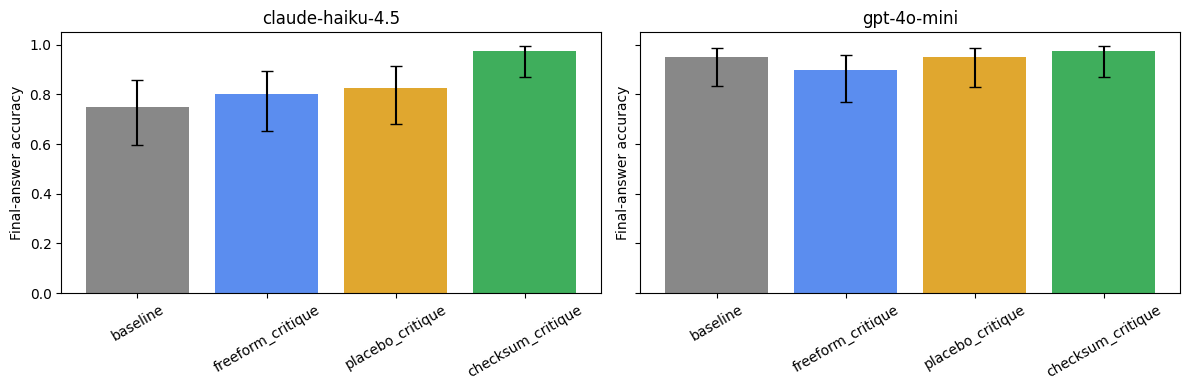

In [9]:
print(f"{'model':<28} {'condition':<22} {'n':>4} {'acc':>7} {'95% CI':>18}")
print("-" * 82)
for model in models:
    for cond in CONDITIONS + ["oracle_detection_isolation"]:
        d = accuracy_table[model][cond]["overall"]
        if d["accuracy"] is None:
            continue
        ci = f"[{d['wilson_ci_low']:.2f}, {d['wilson_ci_high']:.2f}]"
        print(f"{model:<28} {cond:<22} {d['n']:>4} {d['accuracy']:>7.2%} {ci:>18}")

print("\
Metric 5 -- checksum vs freeform/placebo, checksum-detectable subset:")
for model in models:
    for key, entry in significance_table[model].items():
        hb = entry.get("holm_bonferroni", {})
        print(
            f"  {model} | {key}: n_detectable={entry['n_detectable_subset']}, "
            f"effect={entry['effect_size_pp_detectable_subset']:.1f}pp, "
            f"holm_p={hb.get('p_holm_adjusted'):.3f}" if entry['effect_size_pp_detectable_subset'] is not None and hb.get('p_holm_adjusted') is not None
            else f"  {model} | {key}: insufficient data"
        )

fig, axes = plt.subplots(1, len(models), figsize=(6 * len(models), 4), sharey=True)
if len(models) == 1:
    axes = [axes]
for ax, model in zip(axes, models):
    accs = [accuracy_table[model][c]["overall"]["accuracy"] for c in CONDITIONS]
    los = [accuracy_table[model][c]["overall"]["wilson_ci_low"] for c in CONDITIONS]
    his = [accuracy_table[model][c]["overall"]["wilson_ci_high"] for c in CONDITIONS]
    errs = [[a - lo for a, lo in zip(accs, los)], [hi - a for a, hi in zip(accs, his)]]
    ax.bar(CONDITIONS, accs, yerr=errs, capsize=4, color=["#888", "#5b8def", "#e0a72f", "#3fae5c"])
    ax.set_title(model.split("/")[-1])
    ax.set_ylabel("Final-answer accuracy")
    ax.set_ylim(0, 1.05)
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()